#  Прогнозирование заказов такси

<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span><ul class="toc-item"><li><span><a href="#Загрузка-библиотек" data-toc-modified-id="Загрузка-библиотек-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Загрузка библиотек</a></span></li><li><span><a href="#Загрузка-файла-с-данными" data-toc-modified-id="Загрузка-файла-с-данными-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Загрузка файла с данными</a></span></li><li><span><a href="#Изучение-данных" data-toc-modified-id="Изучение-данных-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Изучение данных</a></span></li></ul></li><li><span><a href="#Анализ" data-toc-modified-id="Анализ-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Анализ</a></span><ul class="toc-item"><li><span><a href="#Разведочный-анализ-данных" data-toc-modified-id="Разведочный-анализ-данных-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Разведочный анализ данных</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Обучение</a></span><ul class="toc-item"><li><span><a href="#Создание-признаков" data-toc-modified-id="Создание-признаков-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Создание признаков</a></span></li><li><span><a href="#Разбиение-данных-на-выборки" data-toc-modified-id="Разбиение-данных-на-выборки-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Разбиение данных на выборки</a></span></li><li><span><a href="#LinearRegression" data-toc-modified-id="LinearRegression-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>LinearRegression</a></span></li><li><span><a href="#RandomForestRegressor" data-toc-modified-id="RandomForestRegressor-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>RandomForestRegressor</a></span></li><li><span><a href="#CatBoostRegressor" data-toc-modified-id="CatBoostRegressor-3.5"><span class="toc-item-num">3.5&nbsp;&nbsp;</span>CatBoostRegressor</a></span></li><li><span><a href="#LGBMRegressor" data-toc-modified-id="LGBMRegressor-3.6"><span class="toc-item-num">3.6&nbsp;&nbsp;</span>LGBMRegressor</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-3.7"><span class="toc-item-num">3.7&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Тестирование</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Вывод</a></span></li></ul></div>

## Подготовка

###  Загрузка библиотек

In [1]:
!pip install -q catboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

### Загрузка файла с данными

При чтении файла csv установим индекс DataFrame в первый столбец с датами.

In [3]:
data = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])

In [4]:
data.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


### Изучение данных

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


Набор данных содержит 1 столбец с количеством заказов такси (num_orders), всего 26496 строк. Даты используются в качестве индексов. 

Проверим, являются ли индексы data монотонно возрастающим или убывающим.

In [7]:
data.index.is_monotonic

Монотонно возрастающие данные за полгода: с 2018-03-01 по 2018-08-31

Выполним операцию ресэмплирования. Разобьем данные на интервалы по 1 часу и затем вычисляет сумму значений в каждом из этих интервалов.

In [8]:
data = data.resample('1H').sum()

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


После ресэмплирования у нас осталось 4416 строк

## Анализ

### Разведочный анализ данных

Построим график временных рядов на основе данных из объекта data

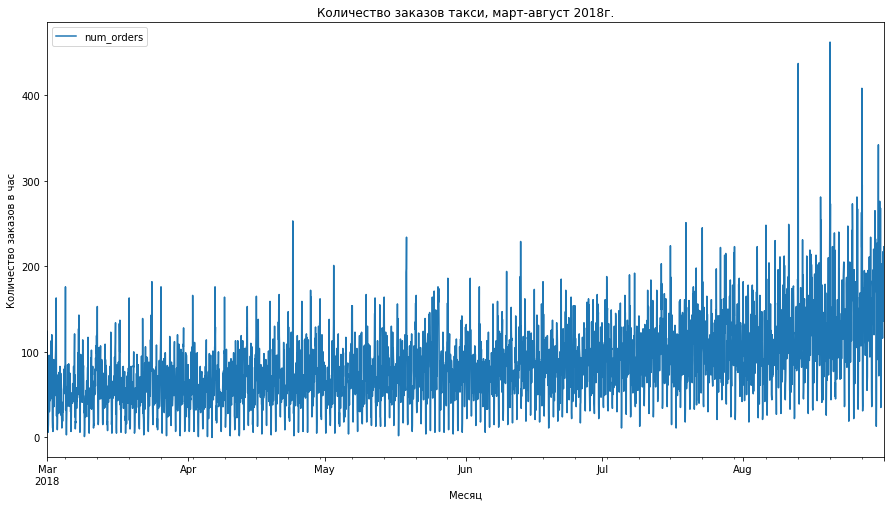

In [10]:
figsize = (15,8)
data.plot(figsize=figsize)
plt.xlabel("Месяц")
plt.ylabel("Количество заказов в час")
plt.title('Количество заказов такси, март-август 2018г.')
plt.show();

Данные имеют большие колебания, но мы уже видим восхдящий тренд вверх в летние месяцы.
Большинство заказов входят в промежуток от 0 до 100. Ближе к сентябрю 2018, кол-во заказов увеличивается.

In [11]:
data.describe()

,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


* В среднем в час 84 заказа такси
* Минимальное количество заказов - 0
* Максимальное количество заказов - 462

Чтобы лучше понимать временной ряд, посмотрим тренды и сезонность.  

* Тренд (англ. trend) — плавное изменение среднего значения ряда без повторяющихся закономерностей.  
* Сезонность (англ. seasonality) — циклично повторяющиеся закономерности во временном ряду.  

Функция seasonal_decompose() принимает временной ряд, а возвращает объект структуры DecomposeResult. В нём есть нужные атрибуты:  

* decomposed.trend — тренд;
* decomposed.seasonal — сезонная составляющая;
* decomposed.resid — остаток декомпозиции.

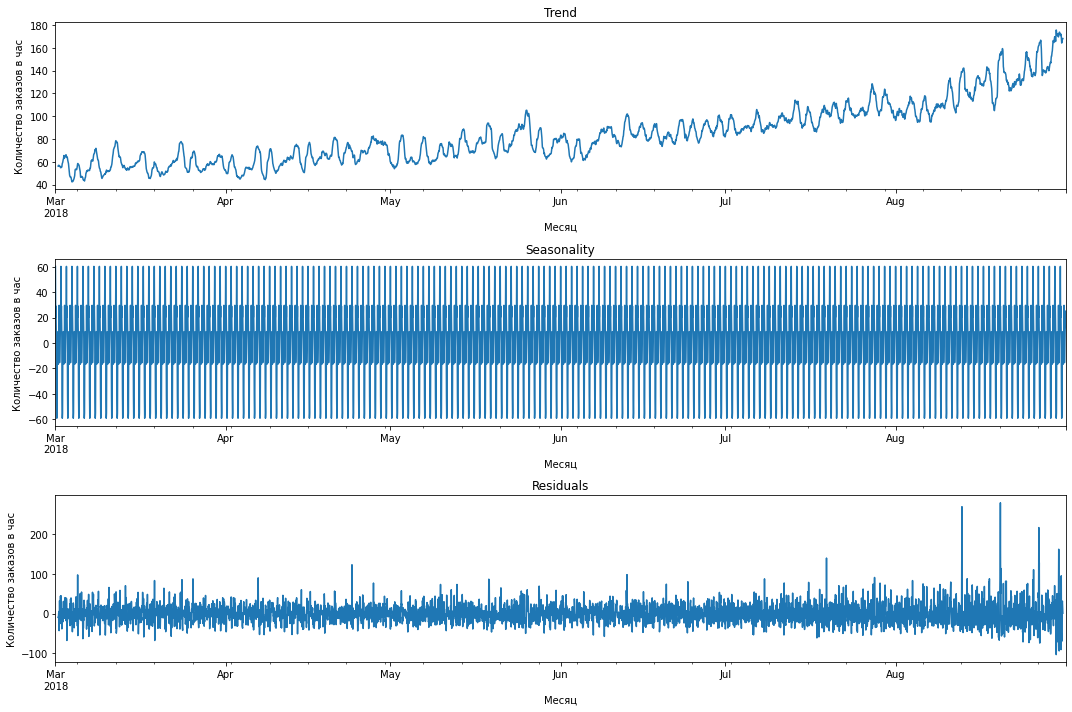

In [12]:
decomposed = seasonal_decompose(data) 

plt.figure(figsize=(15, 10))

#тренд
plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.xlabel("Месяц")
plt.ylabel("Количество заказов в час")
plt.title('Trend')


#сезонная составляющая 
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
plt.xlabel("Месяц")
plt.ylabel("Количество заказов в час")
plt.title('Seasonality')

#остаток декомпозиции, шум
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.xlabel("Месяц")
plt.ylabel("Количество заказов в час")
plt.title('Residuals')

plt.tight_layout()

Графики показывают высокую частотность, уменьшим интервал и посмотрим данные за две недели:

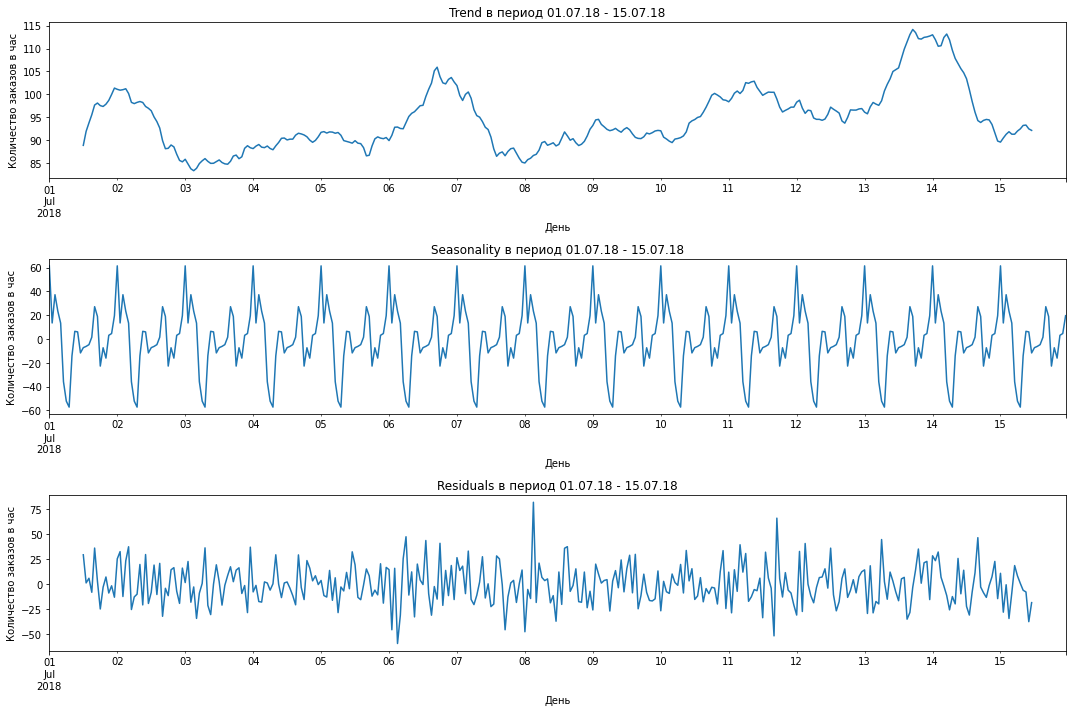

In [13]:
decomposed = seasonal_decompose(data['2018-07-01':'2018-07-15'])

plt.figure(figsize=(15, 10))

plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.xlabel("День")
plt.ylabel("Количество заказов в час")
plt.title('Trend в период 01.07.18 - 15.07.18')

plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
plt.xlabel("День")
plt.ylabel("Количество заказов в час")
plt.title('Seasonality в период 01.07.18 - 15.07.18')

plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.xlabel("День")
plt.ylabel("Количество заказов в час")
plt.title('Residuals в период 01.07.18 - 15.07.18')
plt.tight_layout()

Наблюдается восходящий тренд. Рост весной и ещё более резкий рост в августе связаны, вероятно, активизацией туризма, отпусков.

Явно видна суточная сезонность. Ночью количество заказов стремится к нулю, в то время как вечерами час пик - высокий спрос на услуги такси.

Найдём скользящее среднее и стандартное отклонение

In [14]:
# Создадим копию исходных данных
data_plot = data.copy()

# Вычислим скользящее среднее и стандартное отклонение
data_plot['rolling_mean'] = data_plot['num_orders'].shift().rolling(30).mean()
data_plot['rolling_std'] = data_plot['num_orders'].shift().rolling(15).std()

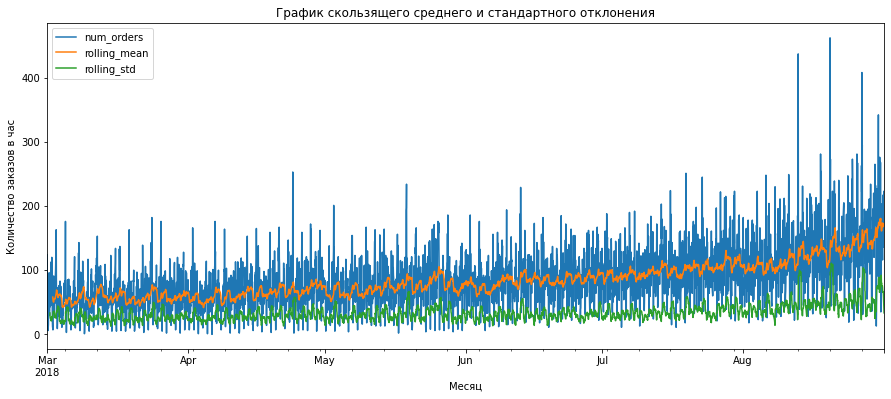

In [15]:
data_plot.plot(figsize=(15, 6))
plt.xlabel("Месяц")
plt.ylabel("Количество заказов в час")
plt.title('График скользящего среднего и стандартного отклонения')
plt.show();

Среднее и стандартное отклонение меняется во времени, таким образом, временные ряды нестационарные.

In [17]:
# Тест Дики-Фуллера
result = adfuller(data)

# Извлечение результатов
adf_statistic = result[0]
p_value = result[1]
critical_values = result[4]

# Вывод результатов
print(f'ADF статистика: {adf_statistic}')
print(f'p-значение: {p_value}')
print('Критические значения:')
for key, value in critical_values.items():
    print(f'   {key}: {value}')

# Проверка на стационарность с уровнями значимости 1% и 5%
alpha_1 = 0.01
alpha_5 = 0.05
if p_value < alpha_1:
    print("Отвергаем нулевую гипотезу на уровне значимости 1%: временной ряд стационарен.")
elif p_value < alpha_5:
    print("Отвергаем нулевую гипотезу на уровне значимости 5%: временной ряд стационарен.")
else:
    print("Не отвергаем нулевую гипотезу: временной ряд нестационарен.")

ADF статистика: -3.0689242890279558
p-значение: 0.028940051402612906
Критические значения:
   1%: -3.431842162413052
   5%: -2.8621993540813637
   10%: -2.567120978470452
Отвергаем нулевую гипотезу на уровне значимости 5%: временной ряд стационарен.


In [18]:
# код ревьюера
# Тест Дики-Фуллера
result = adfuller(data)

# Извлечение результатов
adf_statistic = result[0]
p_value = result[1]
critical_values = result[4]

# Вывод результатов
print(f'ADF статистика: {adf_statistic}')
print(f'p-значение: {p_value}')
print('Критические значения:')
for key, value in critical_values.items():
    print(f'   {key}: {value}')

# Проверка на стационарность с уровнями значимости 1% и 5%
alpha_1 = 0.01
alpha_5 = 0.05
if p_value < alpha_1:
    print("Отвергаем нулевую гипотезу на уровне значимости 1%: временной ряд стационарен.")
else:
    print("Не отвергаем нулевую гипотезу на уровне значимости 1%: временной ряд нестационарен.")
if p_value < alpha_5:
    print("Отвергаем нулевую гипотезу на уровне значимости 5%: временной ряд стационарен.")
else:
    print("Не отвергаем нулевую гипотезу на уровне значимости 5%: временной ряд нестационарен.")

ADF статистика: -3.0689242890279558
p-значение: 0.028940051402612906
Критические значения:
   1%: -3.431842162413052
   5%: -2.8621993540813637
   10%: -2.567120978470452
Не отвергаем нулевую гипотезу на уровне значимости 1%: временной ряд нестационарен.
Отвергаем нулевую гипотезу на уровне значимости 5%: временной ряд стационарен.


### Вывод

На данном этапе исследования проведен анализ данных. 

Методом декомпозиции были выделены следующие аспекты:

* За время наблюдений наметился определенный тренд на увеличение заказов такси весной-летом.
* Обнаружена суточная сезонность. Ночью количество заказов стремится к нулю, в то время как вечерами час пик - высокий спрос на услуги такси.

Временные ряды также не являются стационарными, так как подвержены тренду, который меняется во времени.

## Обучение

### Создание признаков

Обнаруженные наблюдения по трендам и сезонности могут быть полезны при прогнозировании и планировании заказов в будущем.

Создадим календарные признаки для горизонта прогнозирования в один шаг:
* месяц - month
* день - day
* день недели - dayofweek
* час - hour

In [16]:
#Напишем функцию для создания признаков

def make_features(data, max_lag, rolling_mean_size):
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    data['hour'] = data.index.hour
    
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    data['rolling_mean'] = data['num_orders'].shift().rolling(window=rolling_mean_size).mean()

In [17]:
make_features(data, 24, 100)
print(data.head())

                     num_orders  day  dayofweek  hour  lag_1  lag_2  lag_3  \
datetime                                                                     
2018-03-01 00:00:00         124    1          3     0    NaN    NaN    NaN   
2018-03-01 01:00:00          85    1          3     1  124.0    NaN    NaN   
2018-03-01 02:00:00          71    1          3     2   85.0  124.0    NaN   
2018-03-01 03:00:00          66    1          3     3   71.0   85.0  124.0   
2018-03-01 04:00:00          43    1          3     4   66.0   71.0   85.0   

                     lag_4  lag_5  lag_6  ...  lag_16  lag_17  lag_18  lag_19  \
datetime                                  ...                                   
2018-03-01 00:00:00    NaN    NaN    NaN  ...     NaN     NaN     NaN     NaN   
2018-03-01 01:00:00    NaN    NaN    NaN  ...     NaN     NaN     NaN     NaN   
2018-03-01 02:00:00    NaN    NaN    NaN  ...     NaN     NaN     NaN     NaN   
2018-03-01 03:00:00    NaN    NaN    NaN  ...   

### Разбиение данных на выборки

Разделим данные на тренировочную и тестовую выборки. Сделаем тестовую выборку размером 10% от исходных данных.

Функция train_test_split() из модуля sklearn.model_selection по умолчанию перемешивает данные. Поэтому укажем аргумент shuffle равным False, чтобы разделить данные корректно.

In [18]:
train, test = train_test_split(data, shuffle=False, test_size=0.1)
train = train.dropna()

X_train = train.drop('num_orders', axis = 1)
y_train = train['num_orders']
X_test = test.drop('num_orders', axis = 1)
y_test = test['num_orders']

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(3874, 28)
(3874,)
(442, 28)
(442,)


In [19]:
# Создадим DataFrame для хранения результатов тестирования моделей
results = pd.DataFrame(columns=['Model', 'RMSE Train'])

Цель нашего исследования построить модель для предсказания количества заказов такси на следующий час. Предстоит решить задачу **регрессии**.

Будем тестировать четыре модели:

* LinearRegression
* Random Forest Regressor
* CatBoost Regressor
* LGBM Regressor

Для оценки качества моделей будем применять метрику RMSE. Значение RMSE должно быть не больше 48.

### LinearRegression

In [20]:
# Создадим модель
lr_model = LinearRegression()

# Установим random_state
lr_model.random_state = 42

# Создадим объект TimeSeriesSplit для кросс-валидации временных рядов
tscv = TimeSeriesSplit(n_splits=5)

# Создадим объект GridSearchCV с использованием TimeSeriesSplit
grid_search = GridSearchCV(lr_model, {}, cv=tscv, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train, y_train)

best_lr_score = -grid_search.best_score_

print(f'Лучшая оценка качества модели: {best_lr_score}')

# Добавим результаты в таблицу results
results = results.append({
    'Model': 'LinearRegression',
    'RMSE Train': best_lr_score
}, ignore_index=True)

Лучшая оценка качества модели: 27.249090531681567


### RandomForestRegressor

In [21]:
# Определим параметры
param_grid = {
    'n_estimators': range(10, 101, 10),
    'max_depth': range(1, 15)
}

# Создадим модель
forest_model = RandomForestRegressor(random_state=42)

# Создадим объект TimeSeriesSplit для кросс-валидации временных рядов
tscv = TimeSeriesSplit(n_splits=5)

# Создадим объект GridSearchCV с использованием TimeSeriesSplit
grid_search = GridSearchCV(forest_model, param_grid, cv=tscv, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train, y_train)

best_f_params = grid_search.best_params_
best_f_score = -grid_search.best_score_

print(f'Лучшие параметры: {best_f_params}, Лучшая оценка качества модели: {best_f_score}')

# Добавим результаты в таблицу
results = results.append({
    'Model': 'RandomForestRegressor',
    'RMSE Train': best_f_score
}, ignore_index=True)

Лучшие параметры: {'max_depth': 14, 'n_estimators': 100}, Лучшая оценка качества модели: 25.181758903357927


### CatBoostRegressor

In [22]:
# Определим параметры
param_grid = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [4, 6, 8, 10],
    'iterations': [50, 100, 200]
}

# Создадим модель
cb_model = CatBoostRegressor(random_seed=42)

# Создадим объект TimeSeriesSplit для кросс-валидации временных рядов
tscv = TimeSeriesSplit(n_splits=5)

# Создадим объект GridSearchCV с использованием TimeSeriesSplit
grid_search = GridSearchCV(cb_model, param_grid, cv=tscv, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train, y_train)

best_cb_params = grid_search.best_params_
best_cb_score = -grid_search.best_score_

print(f'Лучшие параметры: {best_cb_params}, Лучшая оценка качества модели: {best_cb_score}')

# Добавим результаты 
results = results.append({
    'Model': 'CatBoostRegressor',
    'RMSE Train': best_cb_score
}, ignore_index=True)

0:	learn: 29.0533829	total: 48.8ms	remaining: 2.39s
1:	learn: 28.9217890	total: 50.4ms	remaining: 1.21s
2:	learn: 28.8035202	total: 52ms	remaining: 814ms
3:	learn: 28.6798469	total: 53.5ms	remaining: 616ms
4:	learn: 28.5688289	total: 55ms	remaining: 495ms
5:	learn: 28.4574577	total: 56.4ms	remaining: 414ms
6:	learn: 28.3313908	total: 58ms	remaining: 356ms
7:	learn: 28.2251922	total: 59.5ms	remaining: 312ms
8:	learn: 28.1243311	total: 61ms	remaining: 278ms
9:	learn: 28.0131329	total: 62.6ms	remaining: 250ms
10:	learn: 27.9167081	total: 64ms	remaining: 227ms
11:	learn: 27.8140624	total: 65.6ms	remaining: 208ms
12:	learn: 27.7024643	total: 67ms	remaining: 191ms
13:	learn: 27.5970839	total: 68.5ms	remaining: 176ms
14:	learn: 27.4797218	total: 70ms	remaining: 163ms
15:	learn: 27.3762965	total: 71.4ms	remaining: 152ms
16:	learn: 27.2606700	total: 72.8ms	remaining: 141ms
17:	learn: 27.1639339	total: 74.3ms	remaining: 132ms
18:	learn: 27.0726004	total: 75.7ms	remaining: 124ms
19:	learn: 26.964

### LGBMRegressor

In [23]:
# Определим параметры
param_grid = {
    'n_estimators': [10, 50],
    'max_depth': [None, 3, 5],
    'min_samples_leaf': [1, 2, 4]
}

# Создадим модель
lgbm_model = LGBMRegressor(random_state=42)

# Создадим объект TimeSeriesSplit для кросс-валидации временных рядов
tscv = TimeSeriesSplit(n_splits=5)

# Создадим объект GridSearchCV с использованием TimeSeriesSplit
grid_search = GridSearchCV(lgbm_model, param_grid, cv=tscv, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train, y_train)

best_lgbm_params = grid_search.best_params_
best_lgbm_score = -grid_search.best_score_

print(f'Лучшие параметры: {best_lgbm_params}, Лучшая оценка качества модели: {best_lgbm_score}')

# Добавим результаты в таблицу
results = results.append({
    'Model': 'LGBMRegressor',
    'RMSE Train': best_lgbm_score
}, ignore_index=True)

[LightGBM] [Warning] min_data_in_leaf is set with min_samples_leaf=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_data_in_leaf is set with min_samples_leaf=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_data_in_leaf is set with min_samples_leaf=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_data_in_leaf is set with min_samples_leaf=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_data_in_leaf is set with min_samples_leaf=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_data_in_leaf is set with min_samples_leaf=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_data_in_leaf is set with min_samples_leaf=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[Light

Выведем полученные результаты при тестированнии моделей на тренировочной выборке

In [24]:
results

,Model,RMSE Train
0,LinearRegression,27.249091
1,RandomForestRegressor,25.181759
2,CatBoostRegressor,24.538465
3,LGBMRegressor,25.093123


Лучший результат на тренировочной выборке показала модель CatBoostRegressor, RMSE - 24.54. Эту модель возьмем для обучения на тестовой выборке.

###  Вывод

На данном этапе исследования

* Создали календарные признаки для горизонта прогнозирования в один шаг:

    * месяц - month
    * день - day
    * день недели - dayofweek
    * час - hour

* Разделили данные на тренировочную и тестовую выборки.

* Протестировали разные модели машинного обучения с перебором гиперпараметров на тренировочных данных для решения задачи регрессии:

    * LinearRegression
    * Random Forest Regressor
    * CatBoost Regressor
    * LGBM Regressor

Для оценки качества моделей применили метрику RMSE.

* Лучший результат на тренировочной выборке показала модель CatBoostRegressor, RMSE - 24.54. 
Эту модель возьмем для обучения на тестовой выборке.

## Тестирование

Обучим лучшую модель CatBoostRegressor на тестовой выборке.

In [25]:
# Инициализация модели с лучшими параметрами
best_cb_model = CatBoostRegressor(**best_cb_params)

# Обучение модели на тренировочных данных
best_cb_model.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred_test = best_cb_model.predict(X_test)

# Расчет RMSE
cb_rmse_test = mean_squared_error(y_test, y_pred_test, squared=False)

print(f'RMSE на тестовой выборке: {cb_rmse_test}')

0:	learn: 36.7905750	total: 6.7ms	remaining: 1.33s
1:	learn: 35.0312417	total: 13ms	remaining: 1.29s
2:	learn: 33.6496423	total: 19.1ms	remaining: 1.25s
3:	learn: 32.4109838	total: 24.7ms	remaining: 1.21s
4:	learn: 31.3909571	total: 30.2ms	remaining: 1.18s
5:	learn: 30.4895643	total: 35.8ms	remaining: 1.16s
6:	learn: 29.6635659	total: 41.4ms	remaining: 1.14s
7:	learn: 28.9720668	total: 47.5ms	remaining: 1.14s
8:	learn: 28.3486591	total: 53.6ms	remaining: 1.14s
9:	learn: 27.7189072	total: 59.2ms	remaining: 1.12s
10:	learn: 27.2178113	total: 65.1ms	remaining: 1.12s
11:	learn: 26.6995548	total: 70.9ms	remaining: 1.11s
12:	learn: 26.3128168	total: 76.6ms	remaining: 1.1s
13:	learn: 25.9632113	total: 82.4ms	remaining: 1.09s
14:	learn: 25.5910278	total: 87.8ms	remaining: 1.08s
15:	learn: 25.2695463	total: 93.3ms	remaining: 1.07s
16:	learn: 25.0348588	total: 99.5ms	remaining: 1.07s
17:	learn: 24.8103167	total: 105ms	remaining: 1.06s
18:	learn: 24.6173217	total: 113ms	remaining: 1.07s
19:	learn

Модель CatBoostRegressor на тестовой выборке показала RMSE 42.24, что отвечает условиям задачи (значение метрики RMSE на тестовой выборке должно быть не больше 48).

In [30]:
from sklearn.dummy import DummyRegressor

# создаём dummy-regressor
dummy_regressor = DummyRegressor(strategy='mean')
# обучаем модель на всей тренировочной выборке
dummy_regressor.fit(X_train, y_train)
# делаем предсказание для тестовых данных
predictions = dummy_regressor.predict(X_test)
# находим и выводим mae
print('RMSE: ', mean_squared_error(predictions, y_test)**0.5)

RMSE:  84.33764728516337


Результат RMSE тестирования модели CatBoostRegressor на тествой выборке был лучше, чем результат константной модели. Значит модель адекватна и может использоваться.

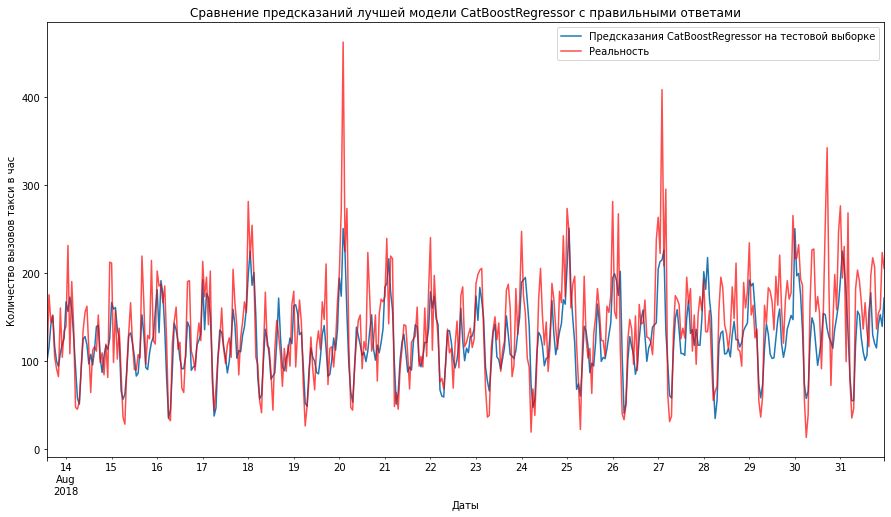

In [33]:
# Создадим series из массива с предсказаниями
predictions_series = pd.Series(data=y_pred_test, index=y_test.index)

# Построим график для предсказанных и реальных значений
predictions_series.plot(figsize=(15, 8), label='Предсказания CatBoostRegressor на тестовой выборке', alpha=1)
y_test.plot(label='Реальность', color='red', alpha=0.7)
plt.legend()
plt.title('Сравнение предсказаний лучшей модели CatBoostRegressor с правильными ответами')
plt.xlabel('Даты')
plt.ylabel('Количество вызовов такси в час')
plt.show()

Лучшая модель CatBoostRegressor более менее правильно предсказывает значения до 200 заказов, не справляется с предсказаниями больш .

## Вывод

Целью исследования было спрогнозировать количество заказов такси на следующий час, построив модель для такого предсказания.
Значение метрики RMSE на тестовой выборке не должно быть больше 48.

Компания предоставила исторические данные о заказах такси в аэропортах за полгода: с 2018-03-01 по 2018-08-31

1. В ходе исследования выполнили операцию ресэмплирования. Разобили данные на интервалы по 1 часу и вычислили сумму заказов в каждом из этих интервалов.

2. Провели исследовательский анализ данных.

Методом декомпозиции выделили следующие аспекты:

* Тренд на увеличение заказов такси весной-летом.
* Суточная сезонность. Ночью количество заказов стремится к нулю, в то время как вечерами час пик - высокий спрос на услуги такси.
* Нестационарность временных рядов

3. Создали календарные признаки для горизонта прогнозирования в один шаг:

* месяц - month
* день - day
* день недели - dayofweek
* час - hour

4. Разделили данные на тренировочную и тестовую выборки.

5. Протестировали разные модели машинного обучения с перебором гиперпараметров на тренировочных данных для решения задачи регрессии:

* LinearRegression
* Random Forest Regressor
* CatBoost Regressor
* LGBM Regressor

Для оценки качества моделей применили метрику RMSE.

Лучший результат на тренировочной выборке показала модель CatBoostRegressor с RMSE 23.32. Эту модель взяли для обучения на тестовой выборке.

6. Обучили лучшую модель CatBoostRegressor на тестовой выборке.
Модель CatBoostRegressor на тестовой выборке показала RMSE 45.66, что отвечает условиям задачи (RMSE должна быть не больше 48).